In [16]:
from collections import Counter
from pathlib import Path
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

dataset_path: Path = Path("Data/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError("Dataset not found")

df = pd.read_csv(str(dataset_path))
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [17]:
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [18]:
len(df)

448000

In [19]:
# --- Toutes les colonnes du dataset ---
COL_ID                          = 'id'
COL_TEXT                        = 'comment_text'
COL_SPLIT                       = 'split'
COL_CREATED                     = 'created_date'
COL_PUBLICATION_ID              = 'publication_id'
COL_PARENT_ID                   = 'parent_id'
COL_ARTICLE_ID                  = 'article_id'
COL_RATING                      = 'rating'
COL_FUNNY                       = 'funny'
COL_WOW                         = 'wow'
COL_SAD                         = 'sad'
COL_LIKES                       = 'likes'
COL_DISAGREE                    = 'disagree'
COL_TOXICITY                    = 'toxicity'
COL_SEVERE_TOXICITY             = 'severe_toxicity'
COL_OBSCENE                     = 'obscene'
COL_SEXUAL_EXPLICIT             = 'sexual_explicit'
COL_IDENTITY_ATTACK             = 'identity_attack'
COL_INSULT                      = 'insult'
COL_THREAT                      = 'threat'
COL_MALE                        = 'male'
COL_FEMALE                      = 'female'
COL_TRANSGENDER                 = 'transgender'
COL_OTHER_GENDER                = 'other_gender'
COL_HETEROSEXUAL                = 'heterosexual'
COL_HOMOSEXUAL                  = 'homosexual_gay_or_lesbian'
COL_BISEXUAL                    = 'bisexual'
COL_OTHER_SEXUAL_ORIENTATION    = 'other_sexual_orientation'
COL_CHRISTIAN                   = 'christian'
COL_JEWISH                      = 'jewish'
COL_MUSLIM                      = 'muslim'
COL_HINDU                       = 'hindu'
COL_BUDDHIST                    = 'buddhist'
COL_ATHEIST                     = 'atheist'
COL_OTHER_RELIGION              = 'other_religion'
COL_BLACK                       = 'black'
COL_WHITE                       = 'white'
COL_ASIAN                       = 'asian'
COL_LATINO                      = 'latino'
COL_OTHER_RACE                  = 'other_race_or_ethnicity'
COL_PHYSICAL_DISABILITY         = 'physical_disability'
COL_INTELLECTUAL_DISABILITY     = 'intellectual_or_learning_disability'
COL_PSYCHIATRIC_DISABILITY      = 'psychiatric_or_mental_illness'
COL_OTHER_DISABILITY            = 'other_disability'
COL_IDENTITY_ANNOTATOR_COUNT    = 'identity_annotator_count'
COL_TOXICITY_ANNOTATOR_COUNT    = 'toxicity_annotator_count'
COL_LGBTQ                       = 'LGBTQ'
COL_OTHER_RELIGIONS             = 'other_religions'
COL_ASIAN_LATINO_ETC            = 'asian_latino_etc'
COL_DISABILITY_ANY              = 'disability_any'
COL_IDENTITY_ANY                = 'identity_any'
COL_NUM_IDENTITIES              = 'num_identities'
COL_MORE_THAN_ONE_IDENTITY      = 'more_than_one_identity'
COL_NA_GENDER                   = 'na_gender'
COL_NA_ORIENTATION              = 'na_orientation'
COL_NA_RELIGION                 = 'na_religion'
COL_NA_RACE                     = 'na_race'
COL_NA_DISABILITY               = 'na_disability'

# --- Colonnes utilisées dans l'analyse ---
ANALYSIS_COLS = [
    COL_TEXT,
    COL_TOXICITY,
    COL_FEMALE,
    COL_MALE,
    COL_BLACK,
    COL_WHITE,
    COL_HOMOSEXUAL,
]

DEMOGRAPHIC_COLS = [c for c in ANALYSIS_COLS if c not in (COL_TEXT, COL_TOXICITY)]


In [20]:
df = df[ANALYSIS_COLS]
df.head()


,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [21]:
df.head(5)

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


## Nettoyage du dataset

In [22]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                     # mentions @user
    text = re.sub(r'[^\w\s]', ' ', text)                 # ponctuation → espace
    text = re.sub(r'\s+', ' ', text).strip()             # espaces multiples
    return text

df[COL_TEXT] = df['comment_text'].map(clean_text)

# Binarisation de la colonne toxicity au seuil 0.5
df['label'] = (df['toxicity'] >= 0.5).astype(int)

print(f"Commentaires toxiques   : {df['label'].sum():,} ({df['label'].mean():.1%})")
print(f"Commentaires non-toxiques: {(df['label']==0).sum():,} ({(df['label']==0).mean():.1%})")


Commentaires toxiques   : 50,794 (11.3%)
Commentaires non-toxiques: 397,206 (88.7%)


## Tokenisation

In [23]:
COL_TOKENIZED = "tok"
COL_N_TOKENS  = "n_tokens"
COL_LEMMAS    = "lemmas"

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text: str) -> tuple[list[str], list[str]]:
    tokens = word_tokenize(text)
    lemmas = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 1
    ]
    return tokens, lemmas

print("Tokenisation + lemmatisation...")
results = [tokenize_and_lemmatize(t) for t in tqdm(df[COL_TEXT], desc="NLTK tokenize/lemmatize")]

df[COL_TOKENIZED] = [r[0] for r in results]
df[COL_N_TOKENS]  = [len(r[0]) for r in results]
df[COL_LEMMAS]    = [r[1] for r in results]

print(f"Tokens moyen / commentaire : {df[COL_N_TOKENS].mean():.1f}")
print(f"Médiane                    : {df[COL_N_TOKENS].median():.0f}")
print(f"Max                        : {df[COL_N_TOKENS].max()}")


Tokens moyen / commentaire : 61.9
Médiane                    : 46
Max                        : 314


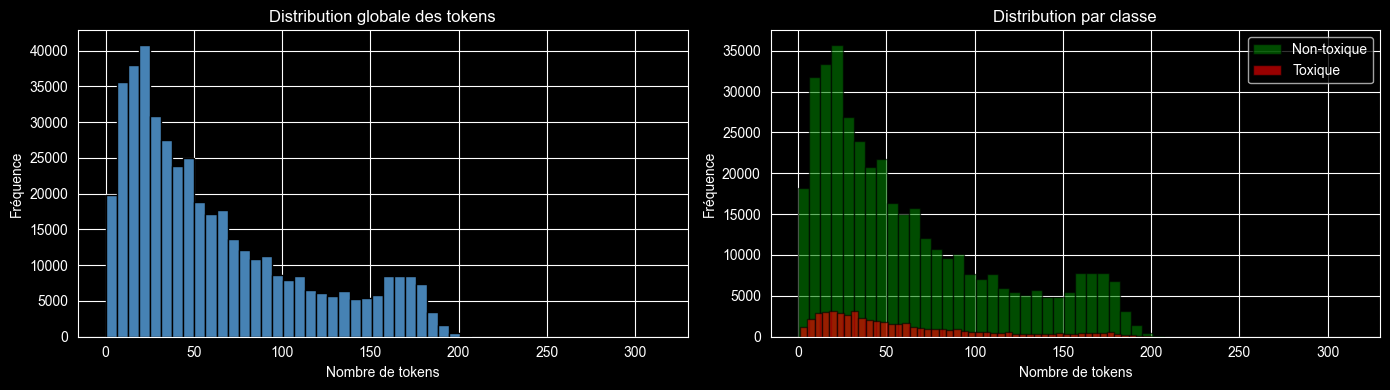

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[COL_N_TOKENS], bins=50, color='steelblue', edgecolor='black')
axes[0].set(title='Distribution globale des tokens', xlabel='Nombre de tokens', ylabel='Fréquence')

for label, color, lbl in [(0, 'green', 'Non-toxique'), (1, 'red', 'Toxique')]:
    subset = df[df['label'] == label][COL_N_TOKENS]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=lbl, edgecolor='black')

axes[1].set(title='Distribution par classe', xlabel='Nombre de tokens', ylabel='Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
df[[COL_TEXT, COL_TOKENIZED, COL_LEMMAS]].head(10)

,comment_text,tok,lemmas
0,oh yes were those evil christian missionaries ...,"[oh, yes, were, those, evil, christian, missio...","[oh, yes, evil, christian, missionary, many, s..."
1,why is this black racist crap still on the g m...,"[why, is, this, black, racist, crap, still, on...","[black, racist, crap, still, website, stopped,..."
2,even up here blacks,"[even, up, here, blacks]","[even, black]"
3,blame men there s always an excuse to blame me...,"[blame, men, there, s, always, an, excuse, to,...","[blame, men, always, excuse, blame, men, failu..."
4,and the woman exposing herself saying grab thi...,"[and, the, woman, exposing, herself, saying, g...","[woman, exposing, saying, grab, pussy, offer, ..."
5,you have no business making any comments on th...,"[you, have, no, business, making, any, comment...","[business, making, comment, site, craig, bigot..."
6,let s get the black folks and the white folks ...,"[let, s, get, the, black, folks, and, the, whi...","[let, get, black, folk, white, folk, others, t..."
7,i guess the issue is people not willing to put...,"[i, guess, the, issue, is, people, not, willin...","[guess, issue, people, willing, put, stupid, c..."
8,jackjohnson5 and they say trump supporters are...,"[jackjohnson5, and, they, say, trump, supporte...","[say, trump, supporter, uneducated, necessaril..."
9,trump could accidently push a button and canad...,"[trump, could, accidently, push, a, button, an...","[trump, could, accidently, push, button, canad..."


## Regroupement par nuage de mots

In [26]:
wc_config = dict(width=800, height=400, max_words=150, background_color='white')

def get_freq(df_subset: pd.DataFrame, col: str = COL_LEMMAS) -> Counter:
    all_tokens = [t for tokens in df_subset[col] for t in tokens]
    return Counter(all_tokens)

freq_toxic    = get_freq(df[df['label'] == 1])
freq_nontoxic = get_freq(df[df['label'] == 0])

# Nuages de mots séparés : toxique vs non-toxique
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_t = WordCloud(colormap='Reds',   **wc_config).generate_from_frequencies(freq_toxic)
wc_n = WordCloud(colormap='Greens', **wc_config).generate_from_frequencies(freq_nontoxic)

axes[0].imshow(wc_t, interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('Commentaires toxiques', fontsize=16)
axes[1].imshow(wc_n, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Commentaires non-toxiques', fontsize=16)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
# Termes ambigus : communs aux deux classes avec un ratio de fréquence proche de 1
total_toxic    = sum(freq_toxic.values())
total_nontoxic = sum(freq_nontoxic.values())
common_terms   = set(freq_toxic) & set(freq_nontoxic)

ambiguity_records = []
for term in common_terms:
    tf_t  = freq_toxic[term]    / total_toxic
    tf_nt = freq_nontoxic[term] / total_nontoxic
    ratio = min(tf_t, tf_nt) / max(tf_t, tf_nt)
    ambiguity_records.append({
        'term': term,
        'freq_toxic': tf_t,
        'freq_nontoxic': tf_nt,
        'ambiguity_score': ratio,
    })

df_ambig = (pd.DataFrame(ambiguity_records)
              .sort_values('ambiguity_score', ascending=False)
              .query('freq_toxic > 1e-4 and freq_nontoxic > 1e-4')
              .reset_index(drop=True))

print("Top 20 termes ambigus (score proche de 1 = présent également dans les deux classes) :")
print(df_ambig.head(20).to_string(index=False))

wc_ambig = WordCloud(colormap='Purples', **wc_config).generate_from_frequencies(
    dict(zip(df_ambig['term'], df_ambig['ambiguity_score']))
)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ambig, interpolation='bilinear')
plt.axis('off')
plt.title('Termes ambigus (communs aux deux classes)', fontsize=16)
plt.show()


## Analyse TF-IDF par classe

In [ ]:
df['lemmas_str'] = [' '.join(lemmas) for lemmas in tqdm(df[COL_LEMMAS], desc="Jointure lemmes")]

N_FEATURES = 20_000

print("Calcul TF-IDF...")
vectorizer = TfidfVectorizer(max_features=N_FEATURES, min_df=5, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(tqdm(df['lemmas_str'], desc="TF-IDF vectorisation"))
vocab = vectorizer.get_feature_names_out()

idx_toxic    = df[df['label'] == 1].index
idx_nontoxic = df[df['label'] == 0].index

mean_tfidf_toxic    = tfidf_matrix[idx_toxic].mean(axis=0).A1
mean_tfidf_nontoxic = tfidf_matrix[idx_nontoxic].mean(axis=0).A1

df_tfidf = pd.DataFrame({
    'term':           vocab,
    'tfidf_toxic':    mean_tfidf_toxic,
    'tfidf_nontoxic': mean_tfidf_nontoxic,
})

TOP_N = 20

df_tfidf['ratio_toxic']    = df_tfidf['tfidf_toxic']    / (df_tfidf['tfidf_nontoxic'] + 1e-9)
df_tfidf['ratio_nontoxic'] = df_tfidf['tfidf_nontoxic'] / (df_tfidf['tfidf_toxic']    + 1e-9)

top_toxic    = df_tfidf.nlargest(TOP_N, 'tfidf_toxic')[['term','tfidf_toxic','tfidf_nontoxic','ratio_toxic']]
top_nontoxic = df_tfidf.nlargest(TOP_N, 'tfidf_nontoxic')[['term','tfidf_nontoxic','tfidf_toxic','ratio_nontoxic']]

print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe TOXIQUE ===")
print(top_toxic.to_string(index=False))
print()
print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe NON-TOXIQUE ===")
print(top_nontoxic.to_string(index=False))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_t = df_tfidf.nlargest(15, 'tfidf_toxic').sort_values('tfidf_toxic')
axes[0].barh(top_t['term'], top_t['tfidf_toxic'], color='tomato')
axes[0].set(title='Top 15 — TF-IDF moyen (classe toxique)', xlabel='TF-IDF moyen')

top_n = df_tfidf.nlargest(15, 'tfidf_nontoxic').sort_values('tfidf_nontoxic')
axes[1].barh(top_n['term'], top_n['tfidf_nontoxic'], color='mediumseagreen')
axes[1].set(title='Top 15 — TF-IDF moyen (classe non-toxique)', xlabel='TF-IDF moyen')

plt.tight_layout()
plt.show()


## Analyse des groupes démographiques

In [ ]:
THRESHOLD = 0.5

records = []
for col in DEMOGRAPHIC_COLS:
    mask = df[col].notna() & (df[col] >= THRESHOLD)
    subset = df[mask]
    n = len(subset)
    if n == 0:
        continue
    tox_rate = subset['label'].mean()
    records.append({
        'groupe': col,
        'n_exemples': n,
        'taux_toxicite': tox_rate,
    })

df_demo = (pd.DataFrame(records)
             .sort_values('taux_toxicite', ascending=False)
             .reset_index(drop=True))

print(df_demo.to_string(index=False))


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['tomato' if r > 0.5 else 'steelblue' for r in df_demo['taux_toxicite']]
bars = ax.barh(df_demo['groupe'], df_demo['taux_toxicite'], color=colors)

global_tox = df['label'].mean()
ax.axvline(global_tox, color='black', linestyle='--', linewidth=1.2,
           label=f'Taux global ({global_tox:.1%})')

for bar, n in zip(bars, df_demo['n_exemples']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'n={n:,}', va='center', fontsize=8)

ax.set(xlabel='Taux de toxicité', title='Taux de toxicité par groupe démographique (seuil ≥ 0.5)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()
